<a href="https://colab.research.google.com/github/dhanusharer/DL-practise/blob/main/keras01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# keras01 — Binary Classification ANN on Churn Modelling Dataset

This notebook builds an **Artificial Neural Network (ANN)** to predict whether a bank customer will churn (leave) or stay, using the **Churn_Modelling** dataset.

### Dataset
- **Source**: `Churn_Modelling.csv`
- **Rows**: 10,000 customers
- **Target**: `Exited` — 1 if the customer left the bank, 0 if they stayed

### Steps:
1. Import libraries
2. Load dataset & select features
3. Encode categorical variables
4. Split & scale the data
5. Build the ANN
6. Train the model
7. Evaluate with predictions & confusion matrix
8. Plot training history

## Cell 1: Import Libraries

Import all the necessary libraries:
- `numpy` and `pandas` for data handling
- `matplotlib` for plotting
- `tensorflow` / `keras` for building the neural network
- `sklearn` for preprocessing and evaluation

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

## Cell 2: Load Dataset & Select Features

- Load `Churn_Modelling.csv` which contains 14 columns.
- Columns 0–2 (`RowNumber`, `CustomerId`, `Surname`) are irrelevant identifiers — skip them.
- **Features (X)**: Columns 3–12 (CreditScore, Geography, Gender, Age, Tenure, Balance, etc.)
- **Target (Y)**: Column 13 — `Exited` (1 = churned, 0 = stayed)

In [6]:
df = pd.read_csv('Churn_Modelling.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

# Features: skip first 3 identifier columns
X = df.iloc[:, 3:13]

# Target: Exited column
Y = df.iloc[:, 13]

print("\nFeature shape:", X.shape)
print("Target distribution:\n", Y.value_counts())

Shape: (10000, 14)

Column names:
 ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Feature shape: (10000, 10)
Target distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## Cell 3: Encode Categorical Variables

The dataset has two categorical columns that cannot be fed directly into a neural network:

- **`Geography`** (France, Spain, Germany) → One-Hot Encoded into binary columns.
  - `drop_first=True` removes one column to avoid the **dummy variable trap** (multicollinearity).
- **`Gender`** (Male, Female) → One-Hot Encoded into a single binary column.

After encoding, the new columns are concatenated to `X` and the original categorical columns are dropped.

In [7]:
# One-Hot Encode Geography (3 categories → 2 binary columns)
geography = pd.get_dummies(X['Geography'], drop_first=True)

# One-Hot Encode Gender (2 categories → 1 binary column)
gender = pd.get_dummies(X['Gender'], drop_first=True)

# Append encoded columns to X
X = pd.concat([X, geography, gender], axis=1)

# Drop original categorical columns
X = X.drop(['Geography', 'Gender'], axis=1)

print("Updated feature columns:", X.columns.tolist())
print("Updated X shape:", X.shape)

Updated feature columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Germany', 'Spain', 'Male']
Updated X shape: (10000, 11)


## Cell 4: Train-Test Split & Feature Scaling

- **Train/Test Split**: 80% training, 20% testing. `random_state=42` ensures reproducibility.
- **StandardScaler**: Transforms features to have **zero mean** and **unit variance**.
  - `fit_transform` on train: learns the mean and std from training data.
  - `transform` on test: applies the same scaling (no leakage from test data).

> ⚠️ Always fit the scaler **only** on training data to avoid data leakage.

In [8]:
# Split into train (80%) and test (20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Scale features — learn from train, apply to both
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

Training set size: (8000, 11)
Test set size: (2000, 11)


## Cell 5: Build the ANN

We create a **Sequential ANN** with the following architecture:

| Layer | Type | Neurons | Activation |
|-------|------|---------|------------|
| 1 | Dense (Input) | 6 | ReLU |
| 2 | Dropout | — | — |
| 3 | Dense (Hidden) | 6 | ReLU |
| 4 | Dropout | — | — |
| 5 | Dense (Output) | 1 | Sigmoid |

### Why these choices?
- **ReLU**: Fast, non-saturating activation for hidden layers. Avoids vanishing gradient.
- **Dropout(0.3)**: Randomly drops 30% of neurons during training to reduce overfitting.
- **Sigmoid**: Outputs a probability between 0 and 1 — perfect for binary classification.
- **`binary_crossentropy`**: Standard loss function for binary (0/1) classification tasks.
- **Adam**: Adaptive learning rate optimizer — generally works well out of the box.

In [9]:
# Initialize the Sequential model
model = Sequential()

# First hidden layer — 6 neurons, ReLU, input shape = number of features
model.add(Dense(units=6, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))  # Drop 30% of neurons to prevent overfitting

# Second hidden layer — 6 neurons, ReLU
model.add(Dense(units=6, activation='relu'))
model.add(Dropout(0.3))

# Output layer — 1 neuron with sigmoid for binary probability output
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

## Cell 6: Train the Model

- **`epochs=100`**: The model passes through the entire training set 100 times.
- **`batch_size=32`**: Weights are updated after every 32 samples (mini-batch gradient descent).
- **`validation_split=0.2`**: 20% of training data is used to track validation loss/accuracy each epoch.

Watching validation accuracy helps detect **overfitting** early — if train accuracy keeps rising but validation plateaus or drops, the model is overfitting.

In [10]:
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7394 - loss: 0.6140 - val_accuracy: 0.7987 - val_loss: 0.5225
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7884 - loss: 0.5472 - val_accuracy: 0.7987 - val_loss: 0.4914
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7917 - loss: 0.5204 - val_accuracy: 0.7987 - val_loss: 0.4757
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5064 - val_accuracy: 0.7987 - val_loss: 0.4658
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7928 - loss: 0.4907 - val_accuracy: 0.7987 - val_loss: 0.4570
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7928 - loss: 0.4860 - val_accuracy: 0.7987 - val_loss: 0.4508
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4804 - val_accuracy: 0.7987 - val_loss: 0.4465
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4757 - val_accu

## Cell 7: Plot Training History

Plot both **accuracy** and **loss** curves for train vs. validation to:
- Check if the model is learning steadily
- Detect overfitting (gap between train and validation curves)
- Decide whether more epochs or regularization is needed

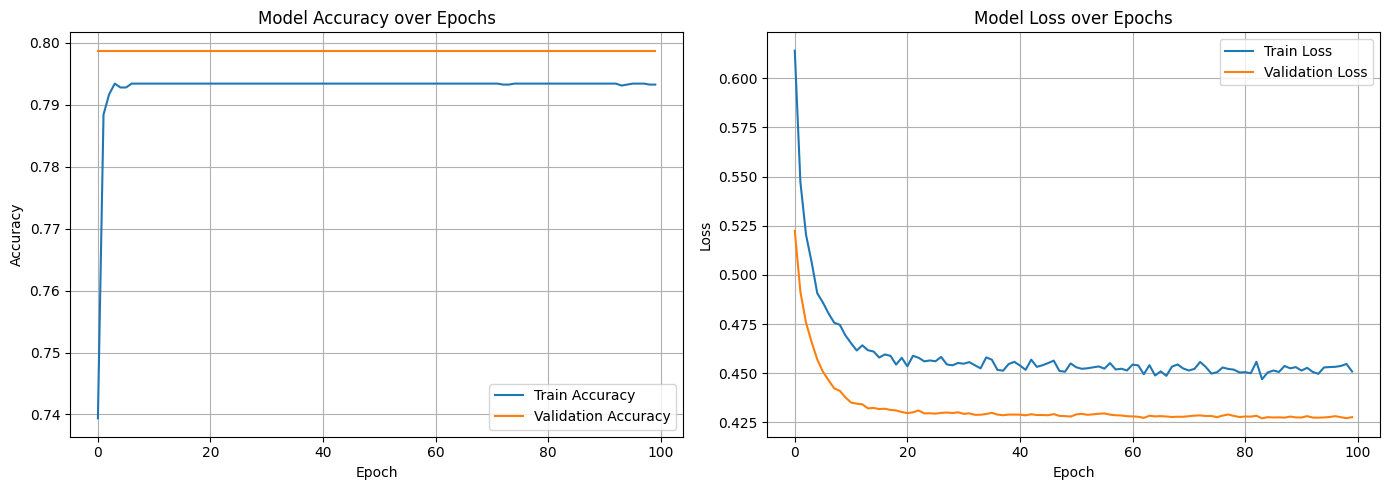

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Plot ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss Plot ---
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Cell 8: Make Predictions

- `model.predict()` returns **probabilities** (values between 0 and 1) for each test sample.
- We apply a **threshold of 0.5**: probabilities above 0.5 are predicted as `1` (churned), below as `0` (stayed).
- This is the standard decision boundary for binary classification.

In [12]:
# Get predicted probabilities from the model
Y_pred_prob = model.predict(X_test)

# Convert probabilities to binary class labels using threshold = 0.5
Y_pred = (Y_pred_prob > 0.5).astype(int)

print("Sample predictions (probabilities):", Y_pred_prob[:5].flatten())
print("Sample predictions (classes):",       Y_pred[:5].flatten())
print("Actual labels:",                       Y_test.values[:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Sample predictions (probabilities): [0.15004297 0.09604042 0.37074193 0.4035699  0.08601985]
Sample predictions (classes): [0 0 0 0 0]
Actual labels: [0 0 0 0 0]


## Cell 9: Evaluate — Confusion Matrix & Accuracy

### Confusion Matrix
A confusion matrix shows how many predictions fell into each of the four categories:

|  | Predicted: Stay (0) | Predicted: Churn (1) |
|--|--|--|
| **Actual: Stay (0)** | True Negative (TN) | False Positive (FP) |
| **Actual: Churn (1)** | False Negative (FN) | True Positive (TP) |

### Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

This tells us the overall proportion of correct predictions.

In [13]:
# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(cm)

# Overall accuracy
acc = accuracy_score(Y_test, Y_pred)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Breakdown from confusion matrix
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted Stay):  {TN}")
print(f"False Positives (wrongly predicted Churn):   {FP}")
print(f"False Negatives (wrongly predicted Stay):    {FN}")
print(f"True Positives  (correctly predicted Churn): {TP}")

Confusion Matrix:
[[1607    0]
 [ 393    0]]

Test Accuracy: 0.8035 (80.35%)

True Negatives  (correctly predicted Stay):  1607
False Positives (wrongly predicted Churn):   0
False Negatives (wrongly predicted Stay):    393
True Positives  (correctly predicted Churn): 0


## Cell 10: Predict on a Single New Customer

Test the trained model on a **single new customer** to demonstrate real-world inference.

The input values represent:
`[CreditScore, Germany, Spain, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Male]`

> ⚠️ The input must be scaled using the **same scaler** fitted on training data before predicting.

In [14]:
# Example: new customer data (must match the feature order after encoding)
# [CreditScore, Germany, Spain, Age, Tenure, Balance, NumProducts, HasCrCard, IsActive, Salary, Male]
new_customer = np.array([[600, 1, 0, 40, 3, 60000, 2, 1, 1, 50000, 1]])

# Apply the same scaling used during training
new_customer_scaled = sc.transform(new_customer)

# Predict probability of churning
churn_probability = model.predict(new_customer_scaled)[0][0]
prediction = "Churn" if churn_probability > 0.5 else "Stay"

print(f"Churn Probability : {churn_probability:.4f}")
print(f"Prediction        : {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Churn Probability : 0.0000
Prediction        : Stay


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
